In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub

In [3]:
df = pd.read_csv("wine-reviews.csv", usecols = ['country', 'description', 'points', 'price', 'variety', 'winery'])

In [4]:
df.head()

,country,description,points,price,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",87,NaN,White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,15.0,Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",87,14.0,Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",87,13.0,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",87,65.0,Pinot Noir,Sweet Cheeks


In [5]:
df = df.dropna(subset=["description", "points"])

In [6]:
df.head()

,country,description,points,price,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",87,NaN,White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,15.0,Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",87,14.0,Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",87,13.0,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",87,65.0,Pinot Noir,Sweet Cheeks


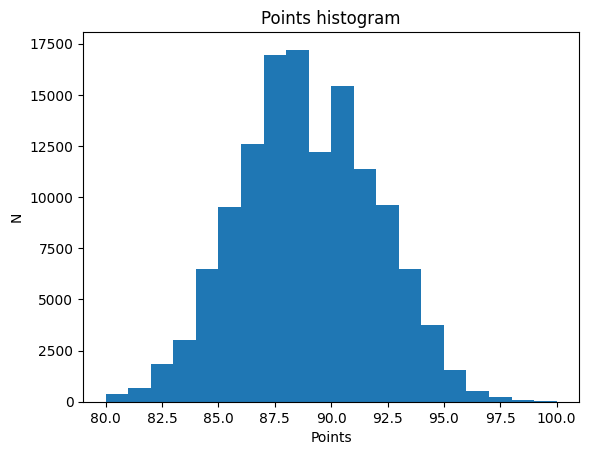

In [7]:
plt.hist(df.points, bins=20)
plt.title("Points histogram")
plt.ylabel("N")
plt.xlabel("Points")
plt.show()

In [8]:
df["label"] = (df.points >= 90).astype(int)
df = df[["description", "label"]]

In [9]:
train, val, test = np.split(df.sample(frac=1), [int(0.8*len(df)), int(0.9*len(df))])

In [10]:
def df_to_dataset(dataframe, shuffle=True, batch_size=1024):
  df = dataframe.copy()
  labels = df.pop('label')
  df = df["description"]
  ds = tf.data.Dataset.from_tensor_slices((df, labels))
  if shuffle:
    ds = ds.shuffle(buffer_size=len(dataframe))
  ds = ds.batch(batch_size)
  ds = ds.prefetch(tf.data.AUTOTUNE)
  return ds

In [19]:
train_data = df_to_dataset(train)
valid_data = df_to_dataset(val)
test_data = df_to_dataset(test)

In [18]:
embedding = "https://tfhub.dev/google/nnlm-en-dim50/2"
hub_layer = hub.KerasLayer(embedding, dtype=tf.string, trainable=True)

In [20]:
hub_layer(list(train_data)[0][0])

<tf.Tensor: shape=(1024, 50), dtype=float32, numpy=
array([[ 0.15964976, -0.04316808, -0.16339345, ..., -0.15597689,
        -0.16875613, -0.10491258],
       [-0.07687885,  0.08458377, -0.06346654, ..., -0.01211022,
        -0.33625036,  0.07117147],
       [ 0.23669928, -0.4188037 , -0.0370834 , ...,  0.18619002,
        -0.18100354, -0.23083025],
       ...,
       [ 0.50659627, -0.12093547,  0.25071636, ...,  0.03574815,
        -0.21870431, -0.1783938 ],
       [ 0.40347272, -0.44882575, -0.20186676, ...,  0.05435619,
         0.06926585, -0.13785973],
       [ 0.30249953, -0.1921197 , -0.1490543 , ..., -0.0317221 ,
        -0.02800463, -0.00970527]], shape=(1024, 50), dtype=float32)>

In [37]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Lambda(lambda x: hub_layer(x)))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dropout(0.4))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [39]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)
model.evaluate(train_data)

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4086 - loss: 0.7033


[0.7032566666603088, 0.408632755279541]

In [40]:
model.evaluate(valid_data)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4089 - loss: 0.7033


[0.7032673358917236, 0.40890204906463623]

In [41]:
history = model.fit(train_data, epochs=5, validation_data=valid_data)

Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5918 - loss: 0.6792 - val_accuracy: 0.6210 - val_loss: 0.6613
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6235 - loss: 0.6593 - val_accuracy: 0.6287 - val_loss: 0.6411
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6421 - loss: 0.6390 - val_accuracy: 0.6731 - val_loss: 0.6127
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6582 - loss: 0.6228 - val_accuracy: 0.6870 - val_loss: 0.5981
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6690 - loss: 0.6123 - val_accuracy: 0.6934 - val_loss: 0.5882


In [42]:
model.evaluate(test_data)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6951 - loss: 0.5868


[0.5868332386016846, 0.6951336860656738]

In [43]:
encoder = tf.keras.layers.TextVectorization(max_tokens=2000)
encoder.adapt(train_data.map(lambda text, label: text))

In [44]:
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'and', 'the', 'a', 'of', 'with', 'this', 'is', 'wine',
       'flavors', 'in', 'it', 'to', 'its', 'on', 'fruit', 'aromas',
       'palate', 'that'], dtype='<U17')

In [45]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=32,
        mask_zero=True
    ),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [46]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

In [47]:
model.evaluate(train_data)
model.evaluate(valid_data)

77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.5275 - loss: 0.6929
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.5292 - loss: 0.6929


[0.6928554773330688, 0.5291990637779236]

In [48]:
history = model.fit(train_data, epochs=5, validation_data=valid_data)

Epoch 1/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - accuracy: 0.6903 - loss: 0.5759 - val_accuracy: 0.7998 - val_loss: 0.4157
Epoch 2/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.8269 - loss: 0.3831 - val_accuracy: 0.8348 - val_loss: 0.3585
Epoch 3/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.8421 - loss: 0.3545 - val_accuracy: 0.8358 - val_loss: 0.3541
Epoch 4/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.8454 - loss: 0.3456 - val_accuracy: 0.8373 - val_loss: 0.3538
Epoch 5/5
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.8471 - loss: 0.3415 - val_accuracy: 0.8398 - val_loss: 0.3505


In [49]:
model.evaluate(test_data)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8432 - loss: 0.3448


[0.3448036015033722, 0.8431621193885803]